# Forced vibration of 2D cylinder

## Prerequisite <a id='prerequisite'></a>

- Before starting this tutorial we recommend to complete the tutorial on `Incompressible Flow Simulation: 2D case` first.  


## Learning Objectives <a id='learningObjectives'></a>

Upon completion of this tutorial, the user will be able to 

- Setup a simulation for forced vibration of cylinder 
- Understand the concept of mapping in Nektar++
- Run the simulaiton and compute various useful runtime quantities

## Introduction <a id='introduction'></a>
In this tutorial we walk through the user how to configure a session file to be able to setup and solve a flow over a moving body with prescribed motion via solving incompressible Navier-Stokes equations for the 2D forced vibration of circular cylinder.


Rest of this tutorial is organised as follows: *Background* briefly introduces the governing equations, concept of tranformed coordinates and description of the problem to be simulated. *Pre-processing* section discusses how to setu a condition file for the problem. *Running the solver* section depicts how incompressilbe flow solver can be run, and finally, *Post-processing* briefly address the post processing of the result.    

- [Background](#background)
- [Pre-processing](#preprocessing)
- [Running the Solver](#basic_runningSolver)
- [Post-processing](#post_filters)
- [References](#references)


## Background <a id='background'></a>

- [Governing equation](#geqn)
- [Problem description](#pdes)

### Governing equations and the Moving body strategy <a id='geqn' ></a>

The incompressible solver implemented in ***Nektar++*** uses the convective form of the Navier-Stokes equations for viscous incompressible and Newtonian fluids together with the divergence-free constraint:

\begin{equation}
\frac{\partial \mathbf{V}}{\partial t}+ \mathbf{V} \cdot \nabla \mathbf{V}=-\nabla p + \nu \nabla ^{2} \mathbf{V} + \mathbf{f}
\end{equation}

\begin{equation}
\nabla \cdot \mathbf{V} =0 
\end{equation}

where ***V***= (*u,v,w*) is the velocity of the fluid in the x, y, and z directions, respectively, $p$ is the specific pressure (including density), $\nu$ is the kinematic viscosity, and $\mathbf{f}$ is the forcing term.  

However, for the case of moving bodies, such as our example in this tutorial, using the above the formulation requires dynamic remeshing as the body moves through the fluid. On way to overcome such difficulty is to use the mapping where the Navier-Stokes equations are mapped (formulated) into the non-inertial-body frame of reference using a general mapping $\mathbf{\bar{X}}\longrightarrow\mathbf{X}$ from cartesian coordinates denoted by overbar to the general coordinate (the body-fitted one). This will results in the transformed Navier-Stokes equations in tensorail notation as follows:

\begin{equation}
\frac{\partial v^i}{\partial t}= v^j \,v^i_{,j}+U^jv^i_{,j}-v^jU^i_{,j}-g^{ij} p_{,j} + \nu g^{jk}v^i_{,jk}
\end{equation}

\begin{equation}
\frac{1}{J} \nabla \cdot (Ju^i) = 0 
\end{equation}

where $v^i$ are the contravariant velocity components, $g^{ij}$ is the transformation metric tensor, $J$ is the transformation Jacobian, the subscript $,j$ means derivative with respect to $j^th$ direction and $U^i=-\frac{\partial x^i}{\partial t}$

Hence, for solving the problem involves moving body, one of the solutions that ***Nektar++*** provides is solving the transformed Navier-Stokes equations. The mapping strategy can also be used for simulation of flows over irregular geomeries if the shape of the body can be defined using a mapping. Here in this tutorial we focus on the solution of flow over a moving cylinder and the irregular geometry is discussed in another tutorial.

### Problem description  <a id='pdes' ></a>

Our geometry consists of a circular cylinder with the unit diameter D=1. For our study we use the following free-stream parameters: A Reynolds number Re = 200 with $Re = UD/\nu$ where U is the velocity scale, D is  the length scale and $\nu$ is the kinematic viscosity. The cylinder moves in the cross flow direction with $y=Acos(\omega t)$ where $A$ is the amplitude and $\omega=2\pi f$ with $f$ is the frequency of motion. This motion results in the cylinder moves with the velocity $v_y=-A\omega sin(\omega t)$. 

The flow domain is consists of a semi-circular domain with radius of $10D$ attach to a rectangluar domain extended $15D$ downstream of the cylinder. The solution domain as well as the motion of the cylinder is shown in the figure.

<table class="center"> 
    <tr> 
    <td> <img src="domain2d.png" width="600" height ="300"/> </td> 
</tr> 
<tr>
     <td style="text-align:center">Figure: Computational Domain</td>
</tr>
</table>
    
The mesh consists of --- quadrilaterals in which we applied the following boundary conditions (BCs): 
- No−slip wall on the cylinder surface 
- Far−field with Dirichlet BC: (u, v) = (1, 0) at the bottom and top boundaries,
- Inflow with Dirichlet BC: (u, v) = (1, 0) at the left boundary (the semi-circle edge of the domain),  
- Outflow (higher order) at the right boundary.

<span style="color:Chocolate"><b>Note:   </b> </span>
For pressure p we used higher order boundary condition. 




## Pre-processing <a id='preprocessing'></a>

- [Expansion bases](#expansionBases)
- [Conditions setup](#conditionsSetup)
- [Mapping](#mapping)
- [Aerodynamic Forces](#aeroForces)

In this section we discuss how to setup the **session** file for our moving cylnder. Here we use two separate xml files: 

(i) mesh xml file which contains the mesh used for the geomtery encompassing the computational domain, <br>
(ii) session (or Conditions) xml file which contains simulation conditions, problem parameters, filters, etc.

<span style="color:Chocolate"><b>Note:   </b> </span>
It is also possible to use a single xml file instead of two. In that case, one needs to copy the ```<GEOMETRY>``` tag from the geometry xml file into the session (condition) xml file to make a single xml file. 

### Expansion bases <a id='expansionBases'></a>
The first tag we define within the `<NEKTAR>` tag is the `<EXPANSIONS>` tag where we tell the solver that use the ***MODIFIED*** expansion with ***NUMMOES=5*** (order ***P=4***) for our varible *u*, *v* and *p* in the domain (the composite **C[73]**):
    
```xml
 <EXPANSIONS>
        <E COMPOSITE="C[73]" NUMMODES="5" FIELDS="u,v,p" TYPE="MODIFIED" /> 
 </EXPANSIONS>`
 ```
 
It is also possible to define different order of polynomial for different variables. For example,

```xml
 <EXPANSIONS>
        <E COMPOSITE="C[73]" NUMMODES="5" FIELDS="u,v" TYPE="MODIFIED" /> 
        <E COMPOSITE="C[73]" NUMMODES="4" FIELDS="p" TYPE="MODIFIEDPLUS1" /> 
 </EXPANSIONS>`
```

In the above, we used polynomial order 4 for variables u and v, but polynomial order 3 for the varialbe p. This This particular example, is actually the ***Taylor-Hood*** elements. Please consult the user guide for more information. 


### Conditions setup <a id='conditionsSetup'></a>
1. [Solver info](#solverInfo)
2. [Parameters](#parameters)
3. [Variables](#variables)
4. [Boundary conditions](#bc)
5. [Mapping functions](#mapfuncs)
6. [Initial conditions](#ic)
- [References](#references)


### 1. Solver info <a id='solverInfo'></a>

In the solverinfo section we need to define several parameters required for the solution algorithm. First of all we tell the ***Nektar*** that we are going to solve the transient Navier-Stokes equation by setting `EQTYPE` to `UnsteadyNavierStokes`. Then, since we are going to use the mapping, we need to set the appropriate velocity-correction scheme by setting the `SolverType` to `VCSMapping`. Further, we are using the second order implicit-explicit time integration, i.e. `IMEXOrder2`. The `SOLVERINFO` tag is shown below. For the through explanation of the parameters in the `SOLVERINFO` tag see the tutorial `Incompressible Flow Simulation: 2D case`

```xml
    <SOLVERINFO>
        
       <I PROPERTY="EQTYPE"                        VALUE="UnsteadyNavierStokes"    />
       <I PROPERTY="SolverType"                    VALUE="VCSMapping"              />
       <I PROPERTY="EvolutionOperator"             VALUE="Nonlinear"               />
       <I PROPERTY="Projection"                    VALUE="Galerkin"                /> 
       <I PROPERTY="TimeIntegrationMethod"         VALUE="IMEXOrder2"              />
       <I PROPERTY="GlobalSysSoln"                 VALUE="XxtMultiLevelStaticCond"/>
    	
   </SOLVERINFO>
```

### 2. Parameters  <a id='parameters'></a>
In `<PARAMETERS>` tag, we define the number of steps, as well as the timestep size as well as the *kinematic viscosity* $\nu$. Furhter, we define several other parameters such as *Re* and *D* for more readable settings and, *f* and *A* for definition of the motion. Further, three parameters `IO_CheckSteps`, `IO_InfoSteps` and `IO_CFLSteps` controls the frequency of writing the results, printing information and estimation and printing the *CFL* number. 

Here, for our example we want the motion of cylinder to be $y=Acos(2\pi f t)=0.025cos(2\pi\times0.2 t)$, hence $A$, $f$ and $\omega=2\pi f$ are set to $A=0.025$, $f=0.2$ and $\omega=2\pi f$

```xml
    <PARAMETERS>`
        
            <P> TimeStep      = 1.0e-2          </P>
            <P> NumSteps      = 10              </P>
            <P> IO_CheckSteps = 5               </P>
            <P> IO_InfoSteps  = 5               </P>
            <P> IO_CFLSteps   = 5               </P>
            <!-- Flow Parameters -->
            <P> D             = 1               </P>
            <P> Uinf          = 1               </P>
            <P> Re            = 200             </P>
            <P> Kinvis        = Uinf*D/Re       </P>
            <P> f             = 0.2             </P> 
            <P> A             = 0.025           </P>
            <P> omega         = 2*PI*f          </P>
     
    </PARAMETERS>`
```
After we do the first short simulaiton, we will change some of these parameters together and solve the problem to see how those will change our results.
Note also that the number of steps here are set to 10 which is far from sufficient. After you run the problem, you can open the ***session2d.xml*** file, change the number of steps to a larger value, e.g. `NumSteps=10000` and run the problem again. The total time $TimeStep\times NumSteps$ should be large enough for the flow to stablish and having sevral periods of vibration during the solution.

### 3. Variables and space co-ordinate  <a id='variables'></a>

In `<VARIABLES>` tag, we define the number (and name) of solution variables. Each variable is prescribed
a unique ID. For the current two-dimensional flow simulation we only need to have velocity components in x and y directions (u and v) and the pressure (p) which are set as follows: 

```xml
    <VARIABLES>

        <V ID="0">u</V>
        <V ID="1">v</V>
        <V ID="2">p</V>
            
   </VARIABLES>
```

### 4. Boundary conditions  <a id='bc'></a>

Boundary conditions are defined by two tags. First we define the boundary regions in the `<BOUNDARYREGIONS>` tag in terms of composite C[ ] entities from the `<GEOMETRY>` tag section of the geometry (mesh) xml file. Each boundary region has a unique ID and are defined as,

```xml
<BOUNDARYREGIONS>

            <B ID="0"> C[74] </B>      <!-- Wall (cyliner) -->
            <B ID="1"> C[76] </B>      <!-- Far Field -->
            <B ID="2"> C[77] </B>      <!-- Outflow -->
            <B ID="3"> C[75] </B>      <!-- Inflow -->
            
 </BOUNDARYREGIONS>
```

For example, here we define composite C[74] which corresponds to the cylinder wall as *wall* with bounday ID =0.

The next tag we define is `<BOUNDARYCONDITIONS>` tag by which we actually specify the boundary conditions for each boundary ID specified in the `<BOUNDARYREGIONS>` tag.

The boundary conditions for Inflow (`ID=3`), outflow (`ID=2`) and the far-field (`ID=1`) are similar to what we have already learned in the tutorial `Incompressible Flow Simulation: 2D case` where for the inflow and farfield we use a prescribed Dirichlet boundary condition for velocities and high-order Neumann boundary condition for pressure and for the outflow we are using the high-order outflow boundary condition. Note the usage of `Uinf` where it was define in the [Parameters](#parameters) and can be easily changed there to reduce the mistakes while changing the flow parameters.

On the other hand, for the cylinder wall, we need to set the no-slip boundary condition and since the cylinder is moving, the no-slip BC becomes zero relative velocity. To define the bondary condition for the moving region, we need to define the condition as `USERDEFINEDTYPE` with `MovingBody` type and set the relative velocites to zero as shown below.
Note that when using the `MovingBody` boundary type, all velocities must have the same type, i.e. both u and v need to be set as `USERDEFINEDTYPE="MovingBody"` but their value can be different, e.g.if we have slip in one direction.

```xml
 <BOUNDARYCONDITIONS>

            <REGION REF="0">
                <D VAR="u" USERDEFINEDTYPE="MovingBody" VALUE="0" />
                <D VAR="v" USERDEFINEDTYPE="MovingBody" VALUE="0" />
                <N VAR="p" USERDEFINEDTYPE="H" VALUE="0" />
            </REGION>
            <REGION REF="1">
                <D VAR="u" VALUE="Uinf" />
                <D VAR="v" VALUE="0" />
                <N VAR="p" USERDEFINEDTYPE="H" VALUE="0" />
            </REGION>
            <REGION REF="2">
                <N VAR="u" USERDEFINEDTYPE="HOutFlow" VALUE="0" />
                <N VAR="v" USERDEFINEDTYPE="HOutFlow" VALUE="0" />
                <D VAR="p" USERDEFINEDTYPE="HOutFlow" VALUE="0" />
            </REGION>
            <REGION REF="3">
                <D VAR="u" VALUE="Uinf" />
                <D VAR="v" VALUE="0" />
                <N VAR="p" USERDEFINEDTYPE="H" VALUE="0" />
            </REGION>
                                  
 </BOUNDARYCONDITIONS>
```

### 5. Mapping functions  <a id='mapfuncs'></a>

To define the mapping tag in the session file, we first need to define the mapping functions which should be defined inside the ``<CONDITIONS>`` tag. These functions defines the ***(x,y)*** location and velocities ***(ux,uy)*** of the cylinder over the time. Note here that the cylinder moves as $y=Acos(\omega t)$, therefore, $x$ coordinates remaines unchanged and since all points on the cylinder (which is rigid here) should be moved according to our motion formula, we define $y = y + Acos(\omega t)$. Below shows definition of the motion (`Mapping`) and velocity (`MappingVel`) functions for `COORDS` and `VEL` parameter in the mapping. These will be set later (see [Mapping](#mapping)) to define the mapping tag for the solver.

```xml
        <FUNCTION NAME="Mapping">
            <E VAR="x" VALUE="x" />
            <E VAR="y" VALUE="y+A*cos(omega*t)" />
        </FUNCTION>
        <FUNCTION NAME="MappingVel">
            <E VAR="vx" VALUE="0.0" />
            <E VAR="vy" VALUE="-1.0*omega*A*sin(omega*t)" />
        </FUNCTION>

```

### 6. Initial conditions  <a id='ic'></a>

We provide the initial conditions as a `FUNCTION` tag with the name "InitialConditions" as,

```xml
<FUNCTION NAME="InitialConditions">
    
                 <E VAR="u" VALUE="Uinf" />
                 <E VAR="v" VALUE="0" />
                 <E VAR="p" VALUE="0" />
                 
 </FUNCTION>
```

This ends the `<CONDITIONS>` tag.

## Mapping<a id='mapping'></a>


`<MAPPING>` tags is used for definition of the mapping in the session (condition) file. This tag should be inside the `<NEKTAR>` tag.

To define the mapping we need to define the mapping type, mapping functions and set the steady/transient type for the mapping. For the mapping type the following options are available in ***Nektar++***:

|Mapping type |$bar{x}$|$bar{y}$|$bar{z}$|
|-----|-------|------|---|
|Translation|$x+f(t)$|$y+g(t)$|$z+h(t)$|
|XofZ|$x+f(z,t)$|$y$|$z$|
|XofXZ|$x+f(x,z,t)$|$y$|$z$|
|XYofZ|$x+f(z,t)$|$y+g(z,t)$|$z$|
|XYofXY|$f(x,y,t)$|$g(x,y,t)$|$z$|
|General|$f(x,y,z,t)$|$g(x,y,z,t)$|$h(x,y,z,t)$|

For our forced vibration problem, we are using mapping of `Translation` type where $f(t)=0$ and $g(t)=Acos(\omega t)$

The mapping tag is set as follows in the session (condition) file:

```xml

  <MAPPING TYPE="Translation">
        <COORDS>Mapping</COORDS>
        <VEL>MappingVel</VEL>
        <TIMEDEPENDENT>True</TIMEDEPENDENT>
   </MAPPING>

```

Note the functions name, i.e. "Mapping" and "MappingVel" provided for `COORDS` and `VEL` respectively. These are the very same functions we have defined in previous section [5.Mapping functions](#mapfuncs)

We are almost done, Only thing remains is to define a `Filter` to monitor the forces on the cylinder as it moves.

## Aerodynamic Forces<a id='aeroForces'></a>

It is often very useful to have the aerodynamic forces acting on the body especially in the case of vibrating cylinder. This can be achieved by setting a `AeroForces` ***Filter*** in the `xml` file inside the `<NEKTAR>` tags. A detailed explanation for this filter can be find in the userguid [1] or in `Incompressible Flow Simulation: 2D case` tutorial.

here is the Aeroforces filter definition for the session file:
 
 ```xml
 <FILTERS>

	<FILTER TYPE="AeroForces">
			<PARAM NAME="OutputFile">DragLift</PARAM>
            <PARAM NAME="OutputFrequency">5</PARAM>
            <PARAM NAME="Boundary">B[0]</PARAM>
     </FILTER>
        
 </FILTERS>
```

Here,
- Parameter `"OutputFile"` is used to name a output file in which data will be stored during the execution. File name can be supplied by the user, here we named it as `DragLift`, hence a file `DragLift.fce` will be created.
- Parameter `"OutputFrequency"` specifies the number of timesteps after which output is written. 
- Parameter `"Boundary"` specifies the Boundary surface(s) on which the forces are to be evaluated. For example, `B[0]` means the forces will be evaluated at Boundary ID=0 (cylinder wall) defined in the `<BOUNDARYREGIONS>` tag.



## Running the solver <a id='basic_runningSolver'></a>

The two xml files provided in this tutorial are:
- mesh file: *mesh.xml*
- Condition file: *session2d.xml*

The flow solvers in Nektar++ can be run either in serial or parallel as:

**For serial running:** 

 `$nekdir/IncNaviarStokesSolver mesh.xml session2d.xml`

**For parallel running:** assuming NP processes

` mpirun -np NP $nekdir/IncNaviarStokesSolver mesh.xml session2d.xml `

First we run the solver in serial. Here we use `!` (the jupyter notebook syntax for bash command) to run the solver in this online interactive tutorial which used Docer imange and Binder to run Nektar++ in the background.

- Please go to the next cell and click the `Run` icon to run the solver.

<span style="color:Chocolate"><b>Note:   </b> </span>
The simulation produces output files as ***mesh_N.chk*** where N=1,2,3,... and ***mesh.fld***. Also, during the simulation forces will be written in the ***DragLift.fce*** file.
 

In [11]:
!IncNavierStokesSolver mesh.xml session2d.xml

/bin/sh: 1: IncNavierStokesSolver: not found


**In parallel:** using 4 processes

In [ ]:
!mpirun -np 4 IncNavierStokesSolver mesh.xml session2d.xml

## Post-processing <a id='post_filters'></a>
- [Plotting AeroForces](#plotAeroF)
- [Visulization of the solution](#visual)
    
### Plotting AeroForces filter data <a id='plotAeroF'></a>

We plot drag force vs time as shown below:

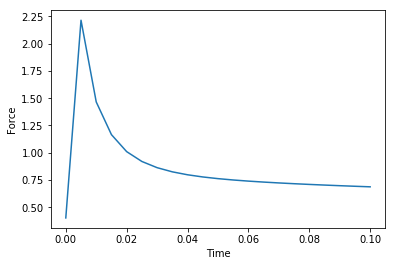

In [10]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

# Read the aerodynamic force file (DragLift.fce)
fileName='DragLift.fce'
fdata = np.loadtxt(fileName,skiprows=5,usecols=(0,3))
# skiprows=5, since first 5 lines in the data file contain notes.
time=fdata[:,0]
f=fdata[:,1]
plt.plot(time,f)
plt.xlabel("Time") 
plt.ylabel("Force")
plt.show()

## Ploting the Lift frequency
We set the motion frequency of the cylinder to `f=0.2`, and since it is the forced vibration, we expect to have a lock-in and the foreces have the same frequency as the body. Lets plot the frequency of the Lift. 
To extract the frequency content of a time data we can use scipy fft module as shown in the next cell. 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft, fftfreq

name = "DragLift.fce"
data = np.genfromtxt(name, dtype=np.float, skip_header=6)

t = data[:,0]
L = data[:,6]
D = data[:,3]

T = 0.01 # time step (change it to the one you have set for your simulation)
N = int(len(t))
N2 = int(N/2)
Lf = fft(L)
xf = fftfreq(N,T)[:N2]

plt.plot(xf, 2.0/N*np.abs(Lf[0:N2]))
plt.xlabel("freq [Hz]")
plt.grid()
plt.show()


### Visualization of the solution <a id='visual'></a>

To visulaize the solution, we need to convert the ***Nektar++*** output to **vtu** format using ***FieldConvert*** utility. Detailed explanations can be found in `Post Processing : Basics of FieldConvert utility` tutorial.

Select the check point file you want to visulaize, for example lets do it together for the first check point: `mesh_1.chk`. To conver the file run the command in the next cell. Note that `-m` is for calling the vorticity module of FieldConvert to compute the vorticity field as well. the result will be wirtten in `out_1.vtu` and using `-f` ensures that the file will be overwritten if already exists. You can choos any name for the output file but the file extension must be `vtu`.

In [ ]:
FieldConvert -f -m vorticity mesh.xml session2d.xml mesh_1.chk out_1.vtu

Now that we convert the solution, lets visualise it using pyvista 

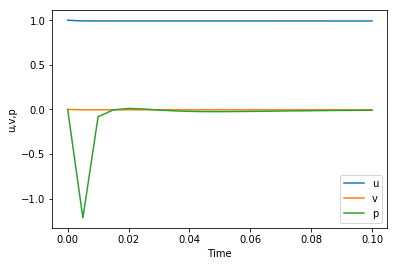

In [7]:
import pyvista as pv

# First read the VTK file
mesh = pv.read('out_1.vtu')

# Now create an itkwidget to visualise this in-browser.
pl = pv.PlotterITK()
pl.add_mesh(mesh, scalars=mesh['W_z'], smooth_shading=True)
pl.show(True)

## Try it yourself

The set up provided here is the basic setup that you can change several parameters and master how to do moving body simulations. Lets do it together:

### <span style="color:Chocolate"><b> Task 1   </b> </span> 
Increase the `NumSteps=10` to `NumSteps=10000` in the ***session2d.xml*** file and run the problem. To reduce the number of outputs, also increase the checkpoint to `IO_CheckSteps= 100`. This means that now the code write the solution every 100 steps (and since $\Delta t=1\times 10^{-2}$, we have outputs every $T=1$ sec.

### <span style="color:Chocolate"><b> Task 2   </b> </span> 
Try changing the frequency and amplititude of the motion. Change `f` and `A` in the `Parameters`. For exapmle you can increase frequency to `f=1` or increase the Amplitude of motion to `A=0.2`. Note that since the velocity maginitude of the prescribed motion directly proportional to both `f` and `A` ($v_y=-A\omega sin(\omega t)$ where $\omega=2\pi f$), hence increase either or both of `f` and `A` will increase the motion velocity and to have a stable solution you should also reduce `TimeStep`. If you have no idea what to set for $\Delta T$, you can start with an estimation from CFL number (lets start with `TimeStep=0.01` and monitor the CFL number. If CFL increased beyond one which lead to divergence of solution, reduce the time step and try again. 

### <span style="color:Chocolate"><b> Task 3   </b> </span> 
Try to have a higher order solution. The mesh file provided has a relatively large elements which are acceptable far from the wake, however, in the wake we need more resolution. Increase `NumModes` in the `<EXPANSIONS>` tag to `NumModes=7` or `NumModes=8` (order 6 or 7). You should note that in the high-order spectral element, the grid distances can be estimated as $dx=\frac{h}{P}$ where $h$ is the element size and $P$ is the order. Hence, increasing the order (NumModes) will actually reduces the effective distances. On the other hand since $\frac{U \Delta t}{\Delta x}=CFL$, increasing the order, reduces $\Delta x$ and we need to reduce $\Delta t$ as well to have a stable solution. 

### <span style="color:Chocolate"><b> Task 4   </b> </span> 
Now try to change the motion of the cylinder. You can define another harmonic function for x direction in the mapping functions (see [5. Mapping functions](#mapfuncs) ). For example lets define a same function with a phase difference with y for x coordinate: $x=A_x cos(\omega t+phi_x)$ and lets set the motion amplitude to $A_x=0.01$ and the phase to $\pi/2$: 
First define two additional parameters in the `<PARAMETERS>` tag:
```xml
<P> Ax = 0.01 </P>
<P> phix = PI/2 </P>
```

Now add this function the mapping functions, note that the $vx$ is obtained by differentiating the motion in x direction:

```xml
<FUNCTION NAME="Mapping">
            <E VAR="x" VALUE="x+Ax*cos(omega*t+phix)" />
            <E VAR="y" VALUE="y+A*cos(omega*t)" />
</FUNCTION>
<FUNCTION NAME="MappingVel">
            <E VAR="vx" VALUE="-1.0*omega*Ax*sin(omega*t+phix)" />
            <E VAR="vy" VALUE="-1.0*omega*A*sin(omega*t)" />
 </FUNCTION>
```
Note that you can set `A`, the amplitude of motion in y direction to `A=0` to have only motion in x direction. 
Also, now that we have motion in both x and y, you need to use smaller timestep. Try to estimate and find an appropriate timestep for the solution.

### <span style="color:Chocolate"><b> Task 5   </b> </span> 
Open the terminal, and convert all of the outputs then load them and make an animation of the flow over the cylinder.
`Hint` You can use the bash command to automate the file conversion. For example if you want to convert the files `mesh_0.chk ... mesh_100.chk` it can be simply done as follows:

`for i in {0..100}; do FieldConvert -f -m mesh.xml session2d.xml mesh_${i}.chk out_${i}.vtu; done`

where after hitting the Enter, the output files `out_0.vtu`, `out_1.vtu` , ..., `out_100.vtu` will be generated can be visualised using the pyvista or paraview.


### Take-a-ways:   <a id='takeaways'> </a>
It is worthy to keep in mind the following points:

- Time step-size should be selected carefully to avoid issues associated with CFL condition. 
- Reynolds number is not directly needed for the incompressible solver. It is the kinematic viscosity that is read by the solver. 
- Increasing the `NumModes` (or equivalently the order) leads to having smaller timesteps
- We can define any motion for the body in x and y, but we should be careful that when we increase the motion velocity, time step should be reduced to have a stable solution


### References:   <a id='references'> </a>
1. Nektar++: Spectral/hp Element Framework, Version 5.0.1, [User guide](http://www.nektar.info/downloads), January, 2021.

### End of the tutorial. 